# A Simple 3D Printing Slicer with Custom Infill

STL in, G-code out. Everything is in **mm** and **degrees C**.

The pipeline, one section per stage:

| # | Stage | What it does |
|---|-------|--------------|
| 1 | `PrintConfig` | All print settings in one place |
| 2 | `load_stl` | Binary + ASCII STL parsing (no mesh library) |
| 3 | `slice_layer` | Triangle/plane intersection -> closed loops -> polygon |
| 4 | `compute_perimeters` | Inward polygon offsets = wall loops |
| 5 | `generate_infill` | **Your curve becomes the infill toolpath** — sweep `f(x)`, parametric `p(t)`, or polar `r(theta)` |
| 6 | `GCodeWriter` | Extrusion math, retraction, temperatures |
| 7 | `slice_model` | Orchestration -> inspectable `SlicedLayer` objects |
| 8 | `plot_layer` | Visual verification |

**Note on the structure:** slicing and G-code emission are deliberately
separate. `slice_model()` returns plain data (`SlicedLayer` objects holding
toolpaths) that you can plot, measure, and experiment on; `layers_to_gcode()`
turns that data into G-code as a second, independent step.

Requires `numpy`, `shapely`, and `matplotlib`.

**Out of scope (by design):** no support material, overhang detection, or
bridging. Assumes a reasonably watertight input mesh.

In [4]:
import math
import struct
import time
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection,
)
from shapely.affinity import rotate as shapely_rotate, translate as shapely_translate

Point2 = Tuple[float, float]      # an (x, y) point
Path2 = List[Point2]              # a polyline / loop
PatternFn = Callable[[float], float]   # a sweep pattern f(x) -> y offset

print(f"numpy {np.__version__}  |  ready")

numpy 2.3.3  |  ready


## 1. Print settings

Everything the slicer needs. Defaults match a typical 0.4 mm nozzle running
1.75 mm filament. `center_x` / `center_y` default to `None`, meaning
"put the model in the middle of the bed".

In [5]:
@dataclass
class PrintConfig:
    # --- Layers / extrusion ---
    layer_height: float = 0.2          # mm, height of each printed layer
    extrusion_width: float = 0.45      # mm, width of a single extruded line
    num_perimeters: int = 2            # number of perimeter (wall) loops
    infill_density: float = 0.2        # fraction 0..1 (0 = none, 1 = solid)

    # --- Hardware ---
    nozzle_diameter: float = 0.4       # mm
    filament_diameter: float = 1.75    # mm

    # --- Temperatures (degrees C) ---
    nozzle_temp: float = 200.0
    bed_temp: float = 60.0

    # --- Speeds (mm/s) ---
    print_speed: float = 40.0          # perimeters / infill
    first_layer_speed: float = 20.0
    travel_speed: float = 120.0

    # --- Retraction ---
    retraction_length: float = 1.0     # mm of filament
    retraction_speed: float = 35.0     # mm/s

    # --- Build plate ---
    bed_size_x: float = 220.0
    bed_size_y: float = 220.0
    # Where to center the model's XY footprint, in bed coordinates (mm).
    # None -> the middle of the bed.
    center_x: Optional[float] = None
    center_y: Optional[float] = None

    # --- Infill ---
    infill_angle: float = 45.0            # degrees, base direction of infill lines
    alternate_infill_angle: bool = True   # rotate 90 deg every other layer
    infill_sample_step: float = 0.5       # mm between curve samples
    optimize_travel: bool = True          # reorder infill paths to cut travel moves

    def __post_init__(self):
        if self.layer_height <= 0:
            raise ValueError("layer_height must be > 0")
        if self.extrusion_width <= 0:
            raise ValueError("extrusion_width must be > 0")
        if self.num_perimeters < 0:
            raise ValueError("num_perimeters must be >= 0")
        if not (0.0 <= self.infill_density <= 1.0):
            raise ValueError("infill_density must be between 0 and 1")
        if self.nozzle_diameter <= 0:
            raise ValueError("nozzle_diameter must be > 0")
        if self.filament_diameter <= 0:
            raise ValueError("filament_diameter must be > 0")

    @property
    def filament_area(self) -> float:
        """Cross-sectional area of the filament (mm^2)."""
        r = self.filament_diameter / 2.0
        return math.pi * r * r

    @property
    def resolved_center_x(self) -> float:
        return self.center_x if self.center_x is not None else self.bed_size_x / 2.0

    @property
    def resolved_center_y(self) -> float:
        return self.center_y if self.center_y is not None else self.bed_size_y / 2.0


cfg = PrintConfig()
print(cfg)
print(f"\nmodel will be centered at ({cfg.resolved_center_x}, {cfg.resolved_center_y}) mm")

PrintConfig(layer_height=0.2, extrusion_width=0.45, num_perimeters=2, infill_density=0.2, nozzle_diameter=0.4, filament_diameter=1.75, nozzle_temp=200.0, bed_temp=60.0, print_speed=40.0, first_layer_speed=20.0, travel_speed=120.0, retraction_length=1.0, retraction_speed=35.0, bed_size_x=220.0, bed_size_y=220.0, center_x=None, center_y=None, infill_angle=45.0, alternate_infill_angle=True, infill_sample_step=0.5, optimize_travel=True)

model will be centered at (110.0, 110.0) mm


## 2. Loading an STL

Binary STL is 80 bytes of header, a `uint32` triangle count, then 50 bytes
per triangle. We detect that exact length; anything else is treated as ASCII.
Returns an `(N, 3, 3)` array of vertex coordinates.

In [6]:
def load_stl(path: str) -> np.ndarray:
    """Load a binary or ASCII STL into an (N, 3, 3) array of triangles."""
    with open(path, "rb") as f:
        f.read(80)          # header
        rest = f.read()

    if len(rest) >= 4:
        (tri_count,) = struct.unpack("<I", rest[:4])
        if 4 + tri_count * 50 == len(rest):
            return _load_binary_stl(rest, tri_count)

    with open(path, "r", errors="ignore") as f:
        text = f.read()
    if "facet" in text.lower():
        return _load_ascii_stl(text)

    raise ValueError(f"Could not parse '{path}' as binary or ASCII STL")


def _load_binary_stl(data: bytes, tri_count: int) -> np.ndarray:
    # Vectorised: view the packed records as a structured array and slice out
    # the 9 vertex floats, skipping the normal and the attribute short.
    record = np.dtype([("normal", "<f4", 3), ("verts", "<f4", (3, 3)), ("attr", "<u2")])
    arr = np.frombuffer(data, dtype=record, count=tri_count, offset=4)
    return arr["verts"].astype(np.float64)


def _load_ascii_stl(text: str) -> np.ndarray:
    triangles, verts = [], []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("vertex"):
            _, x, y, z = line.split()[:4]
            verts.append([float(x), float(y), float(z)])
            if len(verts) == 3:
                triangles.append(verts)
                verts = []
    if not triangles:
        raise ValueError("No triangles found in ASCII STL")
    return np.array(triangles, dtype=np.float64)


def write_binary_stl(path: str, triangles: np.ndarray) -> None:
    """Write triangles out as a binary STL (used to make test parts below)."""
    with open(path, "wb") as f:
        f.write(b"\x00" * 80)
        f.write(struct.pack("<I", len(triangles)))
        for tri in triangles:
            normal = np.cross(tri[1] - tri[0], tri[2] - tri[0])
            n = np.linalg.norm(normal)
            if n > 0:
                normal = normal / n
            f.write(struct.pack("<3f", *normal))
            for v in tri:
                f.write(struct.pack("<3f", *v))
            f.write(struct.pack("<H", 0))

### Test parts

Two shapes to slice: a solid cube, and a square tube whose cross-section has
a real hole in it (that one exercises hole detection).

In [7]:
def box_triangles(sx: float, sy: float, sz: float,
                  ox: float = 0.0, oy: float = 0.0, oz: float = 0.0) -> np.ndarray:
    """Axis-aligned box, size sx x sy x sz, min corner at (ox, oy, oz)."""
    x0, x1 = ox, ox + sx
    y0, y1 = oy, oy + sy
    z0, z1 = oz, oz + sz
    v = {
        "000": (x0, y0, z0), "100": (x1, y0, z0), "110": (x1, y1, z0), "010": (x0, y1, z0),
        "001": (x0, y0, z1), "101": (x1, y0, z1), "111": (x1, y1, z1), "011": (x0, y1, z1),
    }
    faces = [
        ("000", "010", "110"), ("000", "110", "100"),   # bottom
        ("001", "101", "111"), ("001", "111", "011"),   # top
        ("000", "100", "101"), ("000", "101", "001"),   # -y
        ("010", "011", "111"), ("010", "111", "110"),   # +y
        ("000", "001", "011"), ("000", "011", "010"),   # -x
        ("100", "110", "111"), ("100", "111", "101"),   # +x
    ]
    return np.array([[v[a], v[b], v[c]] for a, b, c in faces], dtype=np.float64)


def hollow_box_triangles(size: float = 20.0, wall: float = 4.0,
                         height: float = 10.0) -> np.ndarray:
    """A square tube: outer walls, inner walls, and a ring (annulus) top and
    bottom. Its cross-section is a square with a square hole."""
    inner = size - 2 * wall
    ox0, oy0, ox1, oy1 = 0.0, 0.0, size, size
    ix0, iy0 = wall, wall
    ix1, iy1 = wall + inner, wall + inner
    z0, z1 = 0.0, height

    def quad(p0, p1, p2, p3):
        return [[p0, p1, p2], [p0, p2, p3]]

    tris = []
    # outer walls (normals point outward)
    tris += quad((ox0, oy0, z0), (ox1, oy0, z0), (ox1, oy0, z1), (ox0, oy0, z1))
    tris += quad((ox1, oy0, z0), (ox1, oy1, z0), (ox1, oy1, z1), (ox1, oy0, z1))
    tris += quad((ox1, oy1, z0), (ox0, oy1, z0), (ox0, oy1, z1), (ox1, oy1, z1))
    tris += quad((ox0, oy1, z0), (ox0, oy0, z0), (ox0, oy0, z1), (ox0, oy1, z1))
    # inner walls (reversed winding so normals face into the hole)
    tris += quad((ix0, iy0, z1), (ix1, iy0, z1), (ix1, iy0, z0), (ix0, iy0, z0))
    tris += quad((ix1, iy0, z1), (ix1, iy1, z1), (ix1, iy1, z0), (ix1, iy0, z0))
    tris += quad((ix1, iy1, z1), (ix0, iy1, z1), (ix0, iy1, z0), (ix1, iy1, z0))
    tris += quad((ix0, iy1, z1), (ix0, iy0, z1), (ix0, iy0, z0), (ix0, iy1, z0))

    def ring(z, flip):
        out = []
        outer_pts = [(ox0, oy0, z), (ox1, oy0, z), (ox1, oy1, z), (ox0, oy1, z)]
        inner_pts = [(ix0, iy0, z), (ix1, iy0, z), (ix1, iy1, z), (ix0, iy1, z)]
        for i in range(4):
            o0, o1 = outer_pts[i], outer_pts[(i + 1) % 4]
            i0, i1 = inner_pts[i], inner_pts[(i + 1) % 4]
            out += [[o0, i1, o1], [o0, i0, i1]] if flip else [[o0, o1, i1], [o0, i1, i0]]
        return out

    tris += ring(z1, flip=False)   # top
    tris += ring(z0, flip=True)    # bottom
    return np.array(tris, dtype=np.float64)


def cylinder_triangles(radius: float = 10.0, height: float = 10.0,
                       segments: int = 64) -> np.ndarray:
    """A round part — useful for patterns whose behaviour depends on shape."""
    ang = np.linspace(0.0, 2 * np.pi, segments, endpoint=False)
    rim = np.stack([radius * np.cos(ang), radius * np.sin(ang)], axis=1)
    tris = []
    for i in range(segments):
        (x0, y0), (x1, y1) = rim[i], rim[(i + 1) % segments]
        # side wall
        tris += [[(x0, y0, 0.0), (x1, y1, 0.0), (x1, y1, height)],
                 [(x0, y0, 0.0), (x1, y1, height), (x0, y0, height)]]
        # caps
        tris += [[(0.0, 0.0, height), (x0, y0, height), (x1, y1, height)],
                 [(0.0, 0.0, 0.0), (x1, y1, 0.0), (x0, y0, 0.0)]]
    return np.array(tris, dtype=np.float64)


write_binary_stl("cube.stl", box_triangles(20.0, 20.0, 20.0))
write_binary_stl("hollow_box.stl", hollow_box_triangles())
write_binary_stl("cylinder.stl", cylinder_triangles())

for name in ("cube.stl", "hollow_box.stl", "cylinder.stl"):
    tris = load_stl(name)
    lo, hi = tris.reshape(-1, 3).min(axis=0), tris.reshape(-1, 3).max(axis=0)
    print(f"{name:16s} {len(tris):3d} triangles   bounds {lo} -> {hi}")

cube.stl          12 triangles   bounds [0. 0. 0.] -> [20. 20. 20.]
hollow_box.stl    32 triangles   bounds [0. 0. 0.] -> [20. 20. 10.]
cylinder.stl     256 triangles   bounds [-10. -10.   0.] -> [10. 10. 10.]


## 3. Slicing the mesh

For each layer height Z:

1. **Intersect** every triangle straddling the plane, giving line segments.
2. **Chain** those segments end-to-end into closed loops.
3. **Resolve nesting** — a loop may be an outer boundary or a hole. Sorting
   by area and XOR-ing (symmetric difference) applies the even-odd rule, so
   holes come out right *without* trusting triangle winding order.

Layers are sampled at their *mid-height* so the plane never lands exactly on
the flat top/bottom faces of a model.

In [8]:
_ROUND_DECIMALS = 6   # endpoint matching tolerance (~1 nm at mm scale)


def compute_layer_z_values(triangles: np.ndarray, layer_height: float) -> List[float]:
    z_min = float(triangles[:, :, 2].min())
    z_max = float(triangles[:, :, 2].max())
    n_layers = max(1, int(np.ceil((z_max - z_min) / layer_height)))
    return [z_min + layer_height * (i + 0.5) for i in range(n_layers)]


def _triangle_plane_segment(tri: np.ndarray, z: float):
    """The (p0, p1) XY segment where a triangle crosses plane Z=z, else None."""
    d = tri[:, 2] - z
    # Nudge vertices lying numerically on the plane so signs are never zero.
    d = np.where(np.abs(d) < 1e-9, 1e-9, d)

    pts = []
    for a, b in ((0, 1), (1, 2), (2, 0)):
        da, db = d[a], d[b]
        if (da > 0) != (db > 0):
            t = da / (da - db)
            p = tri[a] + t * (tri[b] - tri[a])
            pts.append((p[0], p[1]))
    return (pts[0], pts[1]) if len(pts) == 2 else None


def _key(p: Point2) -> Point2:
    return (round(p[0], _ROUND_DECIMALS), round(p[1], _ROUND_DECIMALS))


def _chain_segments(segments: List[Tuple[Point2, Point2]]) -> List[Path2]:
    """Chain undirected segments into closed loops by matching endpoints."""
    adjacency: Dict[Point2, List[Point2]] = {}
    for p, q in segments:
        kp, kq = _key(p), _key(q)
        if kp == kq:
            continue                       # degenerate zero-length segment
        adjacency.setdefault(kp, []).append(kq)
        adjacency.setdefault(kq, []).append(kp)

    visited_edges = set()
    loops: List[Path2] = []

    for start in list(adjacency.keys()):
        for first_next in list(adjacency.get(start, [])):
            edge = frozenset((start, first_next))
            if edge in visited_edges:
                continue

            # Walk until we come back to `start`, or get stuck (open contour).
            loop = [start]
            prev, current = start, first_next
            visited_edges.add(edge)
            closed = False
            while True:
                if current == start:
                    closed = True
                    break
                loop.append(current)
                nxt = None
                for cand in adjacency.get(current, []):
                    if frozenset((current, cand)) not in visited_edges and cand != prev:
                        nxt = cand
                        break
                if nxt is None:                       # allow doubling back
                    for cand in adjacency.get(current, []):
                        if frozenset((current, cand)) not in visited_edges:
                            nxt = cand
                            break
                if nxt is None:
                    break                             # dead end; discard chain
                visited_edges.add(frozenset((current, nxt)))
                prev, current = current, nxt

            if closed and len(loop) >= 3:
                loops.append(loop)
    return loops


def slice_layer(triangles: np.ndarray, z: float) -> List[Path2]:
    """Closed XY loops formed by intersecting the mesh with plane Z=z."""
    z_lo = triangles[:, :, 2].min(axis=1)
    z_hi = triangles[:, :, 2].max(axis=1)
    candidates = np.nonzero((z_lo < z) & (z_hi > z))[0]

    segments = []
    for idx in candidates:
        seg = _triangle_plane_segment(triangles[idx], z)
        if seg is not None:
            segments.append(seg)
    return _chain_segments(segments)


def loops_to_polygon(loops: List[Path2]):
    """Combine loops into a shapely (Multi)Polygon, resolving holes via an
    even-odd sweep, so loop winding direction doesn't matter."""
    polys = []
    for loop in loops:
        if len(loop) < 3:
            continue
        poly = Polygon(loop)
        if not poly.is_valid:
            poly = poly.buffer(0)
        if poly.is_empty or poly.area == 0:
            continue
        polys.append(poly)

    if not polys:
        return None

    polys.sort(key=lambda p: p.area, reverse=True)
    result = polys[0]
    for poly in polys[1:]:
        result = result.symmetric_difference(poly)
    return None if result.is_empty else result


# Quick check: the hollow box cross-section should be 20x20 minus 12x12 = 256
_tris = load_stl("hollow_box.stl")
_poly = loops_to_polygon(slice_layer(_tris, 5.0))
print(f"cross-section: {_poly.geom_type}, area {_poly.area:.1f} mm^2, "
      f"{len(_poly.interiors)} hole(s)  (expected 256.0 and 1)")

cross-section: Polygon, area 256.0 mm^2, 1 hole(s)  (expected 256.0 and 1)


## 4. Perimeters and the infill region

Perimeter *n* is the cross-section offset inward by `extrusion_width/2 + n*extrusion_width`
— those offsets are bead **centerlines**, which is what the nozzle follows.
Whatever is left inside the innermost wall gets infill.

In [9]:
def iter_polygons(geom):
    """Yield the individual Polygons of a Polygon / MultiPolygon."""
    if geom is None or geom.is_empty:
        return
    if isinstance(geom, MultiPolygon):
        for p in geom.geoms:
            if not p.is_empty:
                yield p
    elif isinstance(geom, Polygon):
        yield geom


def compute_perimeter_shells(geom, extrusion_width: float,
                             num_perimeters: int) -> List[List[Path2]]:
    """Wall loops grouped by shell, outermost shell first.

    Shell 0 is the wall you can see from outside the part; the rest are
    internal. Keeping them grouped lets the G-code label them correctly.
    """
    shells: List[List[Path2]] = []
    for i in range(num_perimeters):
        distance = extrusion_width / 2.0 + i * extrusion_width
        loops: List[Path2] = []
        for poly in iter_polygons(geom.buffer(-distance, join_style=2)):  # mitre joins
            loops.append(list(poly.exterior.coords))
            loops.extend(list(ring.coords) for ring in poly.interiors)
        shells.append(loops)
    return shells


def compute_perimeters(geom, extrusion_width: float, num_perimeters: int) -> List[Path2]:
    """Wall loops, outermost first, flattened into a single list."""
    return [loop for shell in compute_perimeter_shells(geom, extrusion_width, num_perimeters)
            for loop in shell]


def compute_infill_region(geom, extrusion_width: float, num_perimeters: int):
    """The area inside the innermost perimeter."""
    inset = extrusion_width * num_perimeters
    return geom if inset <= 0 else geom.buffer(-inset, join_style=2)

## 5. Infill patterns

Every layer is a plain **XY plane**, and a pattern is just a set of curves
drawn in it. There are three ways to describe those curves:

| Kind | You write | Example |
|---|---|---|
| `SweepLines` | `f(x) -> y_offset` | `0.6*sin(x)` — wavy parallel lines |
| `Parametric` | `p(t) -> (x, y)` | `(8sin(3t), 8sin(4t))` — a Lissajous figure |
| `Polar` | `r(theta) -> radius` | `1 + 0.35cos(6*theta)` — a flower |

### The coordinate frame

All three are evaluated in a **part-local frame**: the origin `(0, 0)` sits at
the center of the model's footprint, with `x` running along `infill_angle`.
So `r(theta)` spirals out from the middle of the part, and moving the model
around the bed no longer changes the infill it gets. Curves are then clipped
to the infill region and mapped back into bed coordinates.

### Filling an area with a curve

A single closed curve (a circle, a flower) doesn't fill anything on its own,
so each pattern has a **fill strategy**:

- `"once"` — draw the curve as written, in mm. Right for curves that already
  span the part, like a spiral.
- `"nest"` — normalize the curve to radius 1 and redraw it at radius
  `spacing`, `2*spacing`, ... Gives concentric rings, flowers, stars.
- `"tile"` — repeat the motif on a grid across the part.

`spacing` is `extrusion_width / infill_density` throughout, so density means
the same thing for every pattern kind.

**Choosing between `nest` and `tile`:** nesting assumes the curve is
*star-shaped* — one radius per angle, like a circle, rose or star. A curve
that crosses itself (a Lissajous, a knot) will overlap its own scaled copies
when nested, laying plastic on plastic; tile those instead.

In [10]:
@dataclass
class InfillContext:
    """What a pattern is told about the region it has to fill.

    All coordinates are in the part-local frame: (0, 0) is the middle of the
    model's footprint and +x runs along the layer's infill angle.
    """
    bounds: Tuple[float, float, float, float]   # (minx, miny, maxx, maxy)
    spacing: float           # distance between adjacent infill lines (mm)
    extrusion_width: float
    density: float
    sample_step: float       # target distance between sampled curve points (mm)
    layer_index: int         # 0-based; use it to vary the pattern with height
    z: float                 # print height of this layer (mm)
    angle_deg: float         # infill rotation already applied to the frame

    @property
    def max_radius(self) -> float:
        """Distance from the origin to the farthest corner of the region."""
        minx, miny, maxx, maxy = self.bounds
        return max(math.hypot(x, y)
                   for x in (minx, maxx) for y in (miny, maxy))


def _rotate_point(p: Point2, angle_rad: float) -> Point2:
    c, s = math.cos(angle_rad), math.sin(angle_rad)
    return (p[0] * c - p[1] * s, p[0] * s + p[1] * c)


def _extract_lines(geom) -> List[Path2]:
    """Flatten any shapely intersection result into a list of polylines."""
    out: List[Path2] = []
    if geom is None or geom.is_empty:
        return out
    if isinstance(geom, LineString):
        if geom.length > 0:
            out.append(list(geom.coords))
    elif isinstance(geom, (MultiLineString, GeometryCollection)):
        for g in geom.geoms:
            out.extend(_extract_lines(g))
    return out


def _finite_runs(path: Path2) -> List[Path2]:
    """Split a path at any non-finite point, so a function that blows up
    (1/theta at 0, log(0), ...) yields usable pieces instead of an error."""
    runs, current = [], []
    for x, y in path:
        if math.isfinite(x) and math.isfinite(y):
            current.append((x, y))
        else:
            if len(current) >= 2:
                runs.append(current)
            current = []
    if len(current) >= 2:
        runs.append(current)
    return runs


def sample_curve(point_fn: Callable[[float], Point2], t0: float, t1: float,
                 target_step: float, min_points: int = 32,
                 max_points: int = 200_000) -> Path2:
    """Sample a parametric curve so points land roughly `target_step` mm apart.

    Two passes: a coarse probe to estimate arc length, then a resample at the
    density that length implies. Keeps small curves cheap and big ones smooth.
    """
    probe_t = np.linspace(t0, t1, 256)
    probe = np.array([point_fn(t) for t in probe_t], dtype=float)
    finite = probe[np.isfinite(probe).all(axis=1)]
    length = float(np.hypot(*np.diff(finite, axis=0).T).sum()) if len(finite) > 1 else 0.0

    n = int(np.clip(length / max(target_step, 1e-9), min_points, max_points))
    return [point_fn(t) for t in np.linspace(t0, t1, n)]


class InfillPattern:
    """Base class: produce polylines in the part-local frame."""

    def generate(self, ctx: InfillContext) -> List[Path2]:
        raise NotImplementedError


class SweepLines(InfillPattern):
    """Parallel lines bent by `f(x) -> y offset`. The original 1-D model."""

    def __init__(self, f: Optional[PatternFn] = None):
        self.f = f if f is not None else (lambda x: 0.0)

    def generate(self, ctx: InfillContext) -> List[Path2]:
        minx, miny, maxx, maxy = ctx.bounds
        n_lines = max(1, int(math.floor((maxy - miny) / ctx.spacing)) + 1)
        n_samples = max(2, int(math.ceil((maxx - minx) / ctx.sample_step)) + 1)
        xs = np.linspace(minx, maxx, n_samples)

        paths = []
        for i in range(n_lines):
            base_y = miny + (i + 0.5) * ctx.spacing
            if base_y > maxy:
                break
            paths.append([(x, base_y + self.f(x)) for x in xs])
        return paths


class Parametric(InfillPattern):
    """A curve given as `p(t) -> (x, y)`, in mm, in the layer's XY plane."""

    def __init__(self, point_fn: Callable[[float], Point2],
                 t_range: Tuple[float, float] = (0.0, 2 * math.pi),
                 fill: str = "tile",
                 tile: Optional[object] = None,     # scalar or (dx, dy), in mm
                 stagger: float = 0.0,              # offset alternate columns
                 scale: float = 1.0):
        self.point_fn = point_fn
        self.t_range = t_range
        self.fill = fill
        self.tile = tile
        self.stagger = stagger
        self.scale = scale

    def _base_path(self, ctx: InfillContext) -> Path2:
        s = self.scale
        fn = (lambda t: tuple(s * v for v in self.point_fn(t))) if s != 1.0 else self.point_fn
        return sample_curve(fn, *self.t_range, ctx.sample_step)

    def generate(self, ctx: InfillContext) -> List[Path2]:
        base = self._base_path(ctx)
        pts = np.array(base, dtype=float)
        pts = pts[np.isfinite(pts).all(axis=1)]
        if len(pts) < 2:
            return []

        if self.fill == "once":
            return [base]

        if self.fill == "nest":
            radii = np.hypot(pts[:, 0], pts[:, 1])
            rmax = float(radii.max())
            if rmax <= 0:
                return [base]
            return _nest(lambda t: self.point_fn(t), self.t_range, rmax, ctx)

        if self.fill == "tile":
            if self.tile is None:
                w = float(pts[:, 0].max() - pts[:, 0].min())
                h = float(pts[:, 1].max() - pts[:, 1].min())
            elif isinstance(self.tile, (tuple, list)):
                w, h = float(self.tile[0]), float(self.tile[1])
            else:
                w = h = float(self.tile)
            w, h = max(w, 1e-6), max(h, 1e-6)

            minx, miny, maxx, maxy = ctx.bounds
            paths = []
            i0, i1 = int(math.floor(minx / w)) - 1, int(math.ceil(maxx / w)) + 1
            j0, j1 = int(math.floor(miny / h)) - 2, int(math.ceil(maxy / h)) + 1
            for i in range(i0, i1 + 1):
                # `stagger` shifts alternate columns, which is what turns a
                # square grid of hexagons into a real honeycomb.
                offset = h * self.stagger if i % 2 else 0.0
                for j in range(j0, j1 + 1):
                    dx, dy = i * w, j * h + offset
                    paths.append([(x + dx, y + dy) for x, y in base])
            return paths

        raise ValueError(f"unknown fill strategy: {self.fill!r}")


class Polar(InfillPattern):
    """A curve given as `r(theta) -> radius`, centered on the part."""

    def __init__(self, r_fn: Callable[[float], float],
                 theta_range: Tuple[float, float] = (0.0, 2 * math.pi),
                 fill: str = "nest"):
        self.r_fn = r_fn
        self.theta_range = theta_range
        self.fill = fill

    def _point(self, theta: float) -> Point2:
        r = self.r_fn(theta)
        return (r * math.cos(theta), r * math.sin(theta))

    def generate(self, ctx: InfillContext) -> List[Path2]:
        if self.fill == "once":
            return [sample_curve(self._point, *self.theta_range, ctx.sample_step)]

        if self.fill == "nest":
            probe = np.array([abs(self.r_fn(t))
                              for t in np.linspace(*self.theta_range, 512)])
            probe = probe[np.isfinite(probe)]
            rmax = float(probe.max()) if len(probe) else 0.0
            if rmax <= 0:
                return []
            return _nest(self._point, self.theta_range, rmax, ctx)

        raise ValueError(f"unknown fill strategy: {self.fill!r} (use 'nest' or 'once')")


def _nest(point_fn: Callable[[float], Point2], t_range: Tuple[float, float],
          natural_radius: float, ctx: InfillContext) -> List[Path2]:
    """Redraw a curve at radius spacing, 2*spacing, ... out to the region edge."""
    paths = []
    k = 1
    while k * ctx.spacing <= ctx.max_radius + ctx.spacing:
        factor = (k * ctx.spacing) / natural_radius

        def scaled(t, factor=factor):
            x, y = point_fn(t)
            return (factor * x, factor * y)

        paths.append(sample_curve(scaled, *t_range, ctx.sample_step))
        k += 1
    return paths


class FunctionPattern(InfillPattern):
    """Escape hatch: wrap a raw `generator(ctx) -> [path, ...]`, for patterns
    that need to see the spacing or the layer index themselves."""

    def __init__(self, generator: Callable[[InfillContext], List[Path2]]):
        self.generator = generator

    def generate(self, ctx: InfillContext) -> List[Path2]:
        return self.generator(ctx)


def as_pattern(obj) -> InfillPattern:
    """Accept an InfillPattern, or a bare `f(x)` (wrapped as SweepLines)."""
    if isinstance(obj, InfillPattern):
        return obj
    if callable(obj):
        return SweepLines(obj)
    raise TypeError(f"not an infill pattern: {obj!r}")


def straight_line_pattern(x: float) -> float:
    """The default infill pattern: plain straight lines."""
    return 0.0

### Generating and clipping

One shared routine moves into the part-local frame, asks the pattern for its
curves, clips them to the region, and maps the result back to the bed.

In [11]:
def generate_infill(region, cfg: PrintConfig, pattern=straight_line_pattern,
                    layer_index: int = 0, z: float = 0.0,
                    origin: Point2 = (0.0, 0.0)) -> List[Path2]:
    """Fill `region` with `pattern`, returned as polylines in bed coordinates."""
    if region is None or region.is_empty or cfg.infill_density <= 0:
        return []

    pattern = as_pattern(pattern)
    angle = cfg.infill_angle
    if cfg.alternate_infill_angle and layer_index % 2:
        angle += 90.0

    # Bed frame -> part-local frame: move the part center to the origin,
    # then rotate so the infill direction lies along +x.
    ox, oy = origin
    local = shapely_rotate(shapely_translate(region, -ox, -oy), -angle, origin=(0, 0))
    if local.is_empty:
        return []

    ctx = InfillContext(
        bounds=local.bounds,
        spacing=cfg.extrusion_width / cfg.infill_density,
        extrusion_width=cfg.extrusion_width,
        density=cfg.infill_density,
        sample_step=cfg.infill_sample_step,
        layer_index=layer_index,
        z=z,
        angle_deg=angle,
    )

    angle_rad = math.radians(angle)
    out: List[Path2] = []
    for path in pattern.generate(ctx):
        for run in _finite_runs(path):
            clipped = LineString(run).intersection(local)
            for seg in _extract_lines(clipped):
                out.append([(px + ox, py + oy)
                            for px, py in (_rotate_point(p, angle_rad) for p in seg)])
    return out

### A library of patterns

Sweep patterns first (plain `f(x)`), then parametric and polar ones. All of
them are a line or two of maths — that is the whole point of the design.

In [12]:
# --- Sweep patterns: f(x) -> y offset ---------------------------------------
def lines_pattern(x: float) -> float:
    """Straight lines."""
    return 0.0


def sine_pattern(x: float, amplitude: float = 0.6, wavelength: float = 5.0) -> float:
    """Smooth wavy lines."""
    return amplitude * math.sin(2.0 * math.pi * x / wavelength)


def zigzag_pattern(x: float, amplitude: float = 0.6, wavelength: float = 5.0) -> float:
    """Triangle wave."""
    t = (x % wavelength) / wavelength
    return amplitude * -(4 * abs(t - 0.5) - 1)


def square_pattern(x: float, amplitude: float = 0.6, wavelength: float = 5.0) -> float:
    """Square wave (castellated)."""
    return amplitude if (x % wavelength) / wavelength < 0.5 else -amplitude


# --- Polar patterns: r(theta) -> radius --------------------------------------
def concentric_pattern() -> InfillPattern:
    """Concentric circles."""
    return Polar(lambda th: 1.0)


def rose_pattern(petals: int = 6, depth: float = 0.35) -> InfillPattern:
    """Nested flowers: r = 1 + depth*cos(petals*theta)."""
    return Polar(lambda th: 1.0 + depth * math.cos(petals * th))


def star_pattern(points: int = 5, sharpness: float = 0.55) -> InfillPattern:
    """Nested stars, via a triangle wave in theta."""
    def r(th):
        u = (points * th / math.pi) % 2.0        # 0..2 sawtooth
        return 1.0 - sharpness * abs(u - 1.0)
    return Polar(r)


def spiral_pattern(turn_spacing: Optional[float] = None) -> InfillPattern:
    """One continuous Archimedean spiral from the center outwards.

    The pattern emits a single unbroken path. Clipping then cuts it wherever it
    leaves the infill region, so a round part keeps one continuous extrusion
    while a square one ends up with a handful of arcs — still fewer travel
    moves than parallel lines. `turn_spacing` defaults to the normal infill
    line spacing, so `infill_density` still controls it.
    """
    def generate(ctx: InfillContext) -> List[Path2]:
        s = turn_spacing if turn_spacing else ctx.spacing
        theta_max = 2 * math.pi * (ctx.max_radius / s + 1.0)
        a = s / (2 * math.pi)
        return [sample_curve(lambda th: (a * th * math.cos(th), a * th * math.sin(th)),
                             0.0, theta_max, ctx.sample_step)]
    return FunctionPattern(generate)


# --- Parametric patterns: p(t) -> (x, y) -------------------------------------
def lissajous_pattern(a: int = 3, b: int = 4, size: float = 4.0,
                      phase: float = math.pi / 2) -> InfillPattern:
    """A Lissajous figure, tiled across the part.

    Tiled rather than nested: a Lissajous crosses itself, so nesting copies of
    it at every radius would pile extrusions on top of each other.
    """
    return Parametric(lambda t: (size * math.sin(a * t + phase), size * math.sin(b * t)),
                      t_range=(0.0, 2 * math.pi), fill="tile")


def hexagon_pattern(size: float = 4.0) -> InfillPattern:
    """Honeycomb: hexagon outlines on a staggered (hex-packed) grid.

    `size` is the circumradius. Columns are pitched 1.5*size apart and offset
    vertically by half a row, which is what makes the cells interlock.
    """
    pts = [(size * math.cos(k * math.pi / 3), size * math.sin(k * math.pi / 3))
           for k in range(7)]

    def edge(t: float) -> Point2:
        i = min(int(t), 5)
        f = t - i
        (x0, y0), (x1, y1) = pts[i], pts[i + 1]
        return (x0 + f * (x1 - x0), y0 + f * (y1 - y0))

    return Parametric(edge, t_range=(0.0, 6.0), fill="tile",
                      tile=(1.5 * size, math.sqrt(3) * size), stagger=0.5)


def epicycloid_pattern(k: float = 5.0, size: float = 3.0) -> InfillPattern:
    """A rolling-circle curve, nested outwards."""
    return Parametric(
        lambda t: (size * ((k + 1) * math.cos(t) - math.cos((k + 1) * t)),
                   size * ((k + 1) * math.sin(t) - math.sin((k + 1) * t))),
        t_range=(0.0, 2 * math.pi), fill="nest")


SWEEP_PATTERNS: Dict[str, PatternFn] = {
    "lines": lines_pattern,
    "sine": sine_pattern,
    "zigzag": zigzag_pattern,
    "square": square_pattern,
}

PATTERNS: Dict[str, object] = {
    **SWEEP_PATTERNS,
    "concentric": concentric_pattern(),
    "rose": rose_pattern(),
    "star": star_pattern(),
    "spiral": spiral_pattern(),
    "lissajous": lissajous_pattern(),
    "hexagon": hexagon_pattern(),
    "epicycloid": epicycloid_pattern(),
}

print("available patterns:", ", ".join(PATTERNS))

available patterns: lines, sine, zigzag, square, concentric, rose, star, spiral, lissajous, hexagon, epicycloid


## 6. The G-code writer

Extrusion is computed from a rectangular bead: a move of length *L* lays down
`L * extrusion_width * layer_height` mm^3 of plastic, which needs
`volume / filament_area` mm of filament fed in.

Output uses absolute X/Y/Z (`G90`) with relative extrusion (`M83`), so `E` on
each line is just that move's filament, with no running total to drift.

### Tags that make G-code viewers work

Correct coordinates are not enough for a viewer to show the print properly.
PrusaSlicer's G-code viewer (and most others) build their layer list from
extrusion moves that carry a known **role**, **width** and **height**, and
those come from tag comments:

| Tag | Meaning |
|---|---|
| `;LAYER_CHANGE` | a new layer starts here |
| `;Z:<mm>` | the height of that layer |
| `;HEIGHT:<mm>` | how thick the layer is |
| `;WIDTH:<mm>` | how wide the following extrusions are |
| `;TYPE:<role>` | `External perimeter`, `Perimeter`, `Internal infill`, `Custom` |

Without them every move looks like unknown custom G-code with zero width, no
layers get registered, and the viewer draws the whole print as one
unscrollable blob. A human-readable `; LAYER:3` comment does **not** do the
job — the tags above are the ones that get parsed.

In [13]:
class GCodeWriter:
    def __init__(self, config: PrintConfig):
        self.cfg = config
        self.lines: List[str] = []
        self.x: Optional[float] = None
        self.y: Optional[float] = None
        self.z: Optional[float] = None
        self.retracted = False
        self.filament_used = 0.0      # mm of filament extruded
        self._layer_index = -1
        self._type: Optional[str] = None

    # -- low level --------------------------------------------------------
    def comment(self, text: str):
        self.lines.append(f"; {text}")

    def raw(self, line: str):
        self.lines.append(line)

    def _current_speed(self) -> float:
        return self.cfg.first_layer_speed if self._layer_index == 0 else self.cfg.print_speed

    def _extrusion_for_length(self, length: float) -> float:
        """mm of filament for a bead of `length` mm."""
        volume = length * self.cfg.extrusion_width * self.cfg.layer_height
        return volume / self.cfg.filament_area

    # -- moves ------------------------------------------------------------
    def travel_to(self, x: float, y: float):
        if self.x is not None and math.hypot(x - self.x, y - self.y) < 1e-6:
            return
        if not self.retracted and self.cfg.retraction_length > 0:
            self.retract()
        self.raw(f"G0 F{self.cfg.travel_speed * 60:.0f} X{x:.4f} Y{y:.4f}")
        self.x, self.y = x, y

    def extrude_to(self, x: float, y: float, speed: Optional[float] = None):
        if self.x is None:
            self.x, self.y = x, y
            return
        dist = math.hypot(x - self.x, y - self.y)
        if dist < 1e-6:
            return
        if self.retracted:
            self.unretract()
        e = self._extrusion_for_length(dist)
        self.filament_used += e
        mm_s = speed if speed is not None else self._current_speed()
        self.raw(f"G1 F{mm_s * 60:.0f} X{x:.4f} Y{y:.4f} E{e:.5f}")
        self.x, self.y = x, y

    def retract(self):
        if self.cfg.retraction_length <= 0 or self.retracted:
            return
        self.raw(f"G1 F{self.cfg.retraction_speed * 60:.0f} E{-self.cfg.retraction_length:.5f}")
        self.retracted = True

    def unretract(self):
        if self.cfg.retraction_length <= 0 or not self.retracted:
            return
        self.raw(f"G1 F{self.cfg.retraction_speed * 60:.0f} E{self.cfg.retraction_length:.5f}")
        self.retracted = False

    # -- toolpaths --------------------------------------------------------
    def print_path(self, points: Sequence[Point2], closed: bool = False):
        """Travel to the first point, then extrude through the rest."""
        if not points:
            return
        pts = list(points)
        self.travel_to(*pts[0])
        for p in pts[1:]:
            self.extrude_to(*p)
        if closed:
            self.extrude_to(*pts[0])

    # -- structure --------------------------------------------------------
    def set_type(self, role: str):
        """Tag the extrusion role of the moves that follow.

        G-code viewers (PrusaSlicer's included) use these tags to work out
        what each move is and how wide it is. Without them every extrusion
        counts as unknown custom G-code with no width, no layer is ever
        registered, and the whole print renders as a single blob.
        """
        if role == self._type:
            return
        self._type = role
        self.raw(f";TYPE:{role}")
        self.raw(f";WIDTH:{self.cfg.extrusion_width:.4f}")

    def start_layer(self, layer_index: int, z: float):
        self._layer_index = layer_index
        self._type = None                  # re-tag the role after every change
        self.raw(";LAYER_CHANGE")
        self.raw(f";Z:{z:.3f}")
        self.raw(f";HEIGHT:{self.cfg.layer_height:.3f}")
        self.comment(f"LAYER:{layer_index}")
        self.raw(f"G1 F{self.cfg.travel_speed * 60:.0f} Z{z:.4f}")
        self.z = z

    def header(self):
        c = self.cfg
        self.comment("Generated by the notebook slicer")
        self.comment(f"layer_height={c.layer_height} extrusion_width={c.extrusion_width} "
                     f"perimeters={c.num_perimeters} infill_density={c.infill_density}")
        self.comment(f"nozzle_diameter={c.nozzle_diameter}mm "
                     f"filament_diameter={c.filament_diameter}mm")
        self.raw("G21 ; units: millimeters")
        self.raw("G90 ; absolute X/Y/Z positioning")
        self.raw("M83 ; relative extrusion")
        self.raw(f"M140 S{c.bed_temp:.1f} ; set bed temp, don't wait")
        self.raw(f"M104 S{c.nozzle_temp:.1f} ; set nozzle temp, don't wait")
        self.raw(f"M190 S{c.bed_temp:.1f} ; wait for bed temp")
        self.raw(f"M109 S{c.nozzle_temp:.1f} ; wait for nozzle temp")
        self.raw(";TYPE:Custom")
        self.raw("G28 ; home all axes")
        self.raw("G92 E0 ; reset extruder position")

    def footer(self):
        self.raw(";TYPE:Custom")
        self.comment("End of print")
        self.retract()
        self.raw("M104 S0 ; nozzle heater off")
        self.raw("M140 S0 ; bed heater off")
        self.raw("M84 ; disable motors")
        self.comment(f"filament used: {self.filament_used:.1f} mm")

    def to_string(self) -> str:
        return "\n".join(self.lines) + "\n"

## 7. Putting it together

`slice_model()` returns a list of `SlicedLayer` objects — plain data holding
the toolpaths and the cross-section polygon. Nothing about G-code is involved
yet, which is what makes the layers easy to plot and measure.

`layers_to_gcode()` is the separate second step.

In [14]:
@dataclass
class SlicedLayer:
    index: int
    slice_z: float                          # height the mesh was sampled at
    print_z: float                          # nozzle height when printing it
    polygon: Optional[object] = None        # shapely cross-section
    perimeters: List[Path2] = field(default_factory=list)
    infill: List[Path2] = field(default_factory=list)
    # Extrusion role per perimeter loop, same length as `perimeters`.
    perimeter_roles: List[str] = field(default_factory=list)

    @property
    def path_length(self) -> float:
        """Total extruded distance in this layer (mm)."""
        total = 0.0
        for path in list(self.perimeters) + list(self.infill):
            pts = np.asarray(path)
            if len(pts) > 1:
                total += float(np.hypot(*np.diff(pts, axis=0).T).sum())
        return total


def center_mesh_on_bed(triangles: np.ndarray, cfg: PrintConfig) -> np.ndarray:
    """Center the model's footprint on the bed and drop it onto Z=0."""
    xs, ys, zs = triangles[:, :, 0], triangles[:, :, 1], triangles[:, :, 2]
    out = triangles.copy()
    out[:, :, 0] += cfg.resolved_center_x - (xs.min() + xs.max()) / 2.0
    out[:, :, 1] += cfg.resolved_center_y - (ys.min() + ys.max()) / 2.0
    out[:, :, 2] += -zs.min()
    return out


def slice_model(triangles: np.ndarray, cfg: PrintConfig,
                pattern=straight_line_pattern,
                center: bool = True, verbose: bool = True) -> List[SlicedLayer]:
    """Slice a mesh into per-layer toolpaths. No G-code involved.

    `pattern` is an InfillPattern (SweepLines / Parametric / Polar / ...) or a
    bare `f(x)`, which is wrapped as SweepLines for backwards compatibility.
    """
    if triangles.shape[0] == 0:
        raise ValueError("mesh contains no triangles")
    if center:
        triangles = center_mesh_on_bed(triangles, cfg)

    # One fixed origin for the whole model, so patterns line up from layer to
    # layer instead of drifting with each cross-section's own centroid.
    xs, ys = triangles[:, :, 0], triangles[:, :, 1]
    origin = (float((xs.min() + xs.max()) / 2.0), float((ys.min() + ys.max()) / 2.0))

    start = time.time()
    layers: List[SlicedLayer] = []
    for i, z in enumerate(compute_layer_z_values(triangles, cfg.layer_height)):
        layer = SlicedLayer(index=i, slice_z=z, print_z=(i + 1) * cfg.layer_height)

        polygon = loops_to_polygon(slice_layer(triangles, z))
        if polygon is not None and not polygon.is_empty:
            layer.polygon = polygon
            shells = compute_perimeter_shells(
                polygon, cfg.extrusion_width, cfg.num_perimeters)
            layer.perimeters = [loop for shell in shells for loop in shell]
            layer.perimeter_roles = [
                "External perimeter" if s == 0 else "Perimeter"
                for s, shell in enumerate(shells) for _ in shell]
            layer.infill = generate_infill(
                compute_infill_region(polygon, cfg.extrusion_width, cfg.num_perimeters),
                cfg, pattern=pattern, layer_index=i, z=layer.print_z, origin=origin)
        layers.append(layer)

    if verbose:
        total = sum(l.path_length for l in layers)
        print(f"sliced {len(layers)} layers in {time.time() - start:.2f}s  |  "
              f"{total / 1000:.1f} m of extrusion path")
    return layers


def order_paths(paths: Sequence[Path2], start: Point2 = (0.0, 0.0)) -> List[Path2]:
    """Greedy nearest-neighbour ordering, reversing paths when that helps.

    Patterns like nested rings emit many separate curves; printing them in
    generation order can mean a long hop between each one. This picks the
    nearest remaining endpoint each time instead.
    """
    if not paths:
        return []
    starts = np.array([p[0] for p in paths], dtype=float)
    ends = np.array([p[-1] for p in paths], dtype=float)
    remaining = np.ones(len(paths), dtype=bool)

    out: List[Path2] = []
    cur = np.array(start, dtype=float)
    for _ in range(len(paths)):
        idx = np.nonzero(remaining)[0]
        d_start = np.hypot(*(starts[idx] - cur).T)
        d_end = np.hypot(*(ends[idx] - cur).T)
        use_end = d_end < d_start
        best = int(np.argmin(np.where(use_end, d_end, d_start)))
        i = int(idx[best])
        path = list(paths[i])[::-1] if use_end[best] else list(paths[i])
        out.append(path)
        cur = np.array(path[-1], dtype=float)
        remaining[i] = False
    return out


def layers_to_gcode(layers: Sequence[SlicedLayer], cfg: PrintConfig) -> str:
    """Emit G-code for already-sliced layers."""
    w = GCodeWriter(cfg)
    w.header()
    for layer in layers:
        w.start_layer(layer.index, layer.print_z)

        roles = layer.perimeter_roles or ["Perimeter"] * len(layer.perimeters)
        for loop, role in zip(layer.perimeters, roles):
            w.set_type(role)
            w.print_path(loop, closed=True)

        infill = layer.infill
        if cfg.optimize_travel and infill:
            here = (w.x, w.y) if w.x is not None else (0.0, 0.0)
            infill = order_paths(infill, start=here)
        if infill:
            w.set_type("Internal infill")
        for path in infill:
            w.print_path(path, closed=False)
    w.footer()
    return w.to_string()


def slice_stl_to_gcode(stl_path: str, output_path: str, cfg: PrintConfig,
                       pattern: PatternFn = straight_line_pattern) -> List[SlicedLayer]:
    """Convenience: STL file in, G-code file out. Returns the sliced layers."""
    layers = slice_model(load_stl(stl_path), cfg, pattern=pattern)
    gcode = layers_to_gcode(layers, cfg)
    with open(output_path, "w") as f:
        f.write(gcode)
    print(f"wrote {output_path}  ({len(gcode.splitlines())} lines)")
    return layers

## 8. Visualizing a layer

Perimeters in blue, infill in orange, the cross-section shaded behind them.
This is the fastest way to tell whether a new `f(x)` actually does what you
hoped before sending anything to a printer.

In [15]:
def plot_layer(layer: SlicedLayer, ax=None, title: Optional[str] = None,
               show_bed: bool = False, cfg: Optional[PrintConfig] = None,
               margin: float = 2.0):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    for poly in iter_polygons(layer.polygon):
        ax.fill(*poly.exterior.xy, color="0.90", zorder=0)
        for interior in poly.interiors:
            ax.fill(*interior.xy, color="white", zorder=0.5)

    for loop in layer.perimeters:
        xs, ys = zip(*loop)
        ax.plot(xs, ys, color="#1f77b4", lw=1.4, zorder=3)
    for path in layer.infill:
        xs, ys = zip(*path)
        ax.plot(xs, ys, color="#ff7f0e", lw=1.0, zorder=2)

    ax.set_aspect("equal")
    ax.set_title(title or f"layer {layer.index}  (z = {layer.print_z:.2f} mm)")
    if show_bed and cfg is not None:
        ax.set_xlim(0, cfg.bed_size_x)
        ax.set_ylim(0, cfg.bed_size_y)
        ax.add_patch(plt.Rectangle((0, 0), cfg.bed_size_x, cfg.bed_size_y,
                                   fill=False, ec="0.7", ls="--"))
    elif layer.polygon is not None:
        minx, miny, maxx, maxy = layer.polygon.bounds
        ax.set_xlim(minx - margin, maxx + margin)
        ax.set_ylim(miny - margin, maxy + margin)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    return ax


def plot_toolpaths_3d(layers: Sequence[SlicedLayer], every: int = 4,
                      figsize: Tuple[float, float] = (7, 6)):
    """Stack every Nth layer's toolpaths into a quick 3D preview."""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    for layer in layers[::every]:
        for loop in layer.perimeters:
            xs, ys = zip(*loop)
            ax.plot(xs, ys, zs=layer.print_z, color="#1f77b4", lw=0.5)
        for path in layer.infill:
            xs, ys = zip(*path)
            ax.plot(xs, ys, zs=layer.print_z, color="#ff7f0e", lw=0.4, alpha=0.7)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_zlabel("z (mm)")
    ax.set_title(f"toolpaths, every {every}th layer")
    return ax

## 9. Slice something

The hollow box first — its square hole is the interesting case, since the
perimeters have to wrap the hole and the infill has to stay out of it.

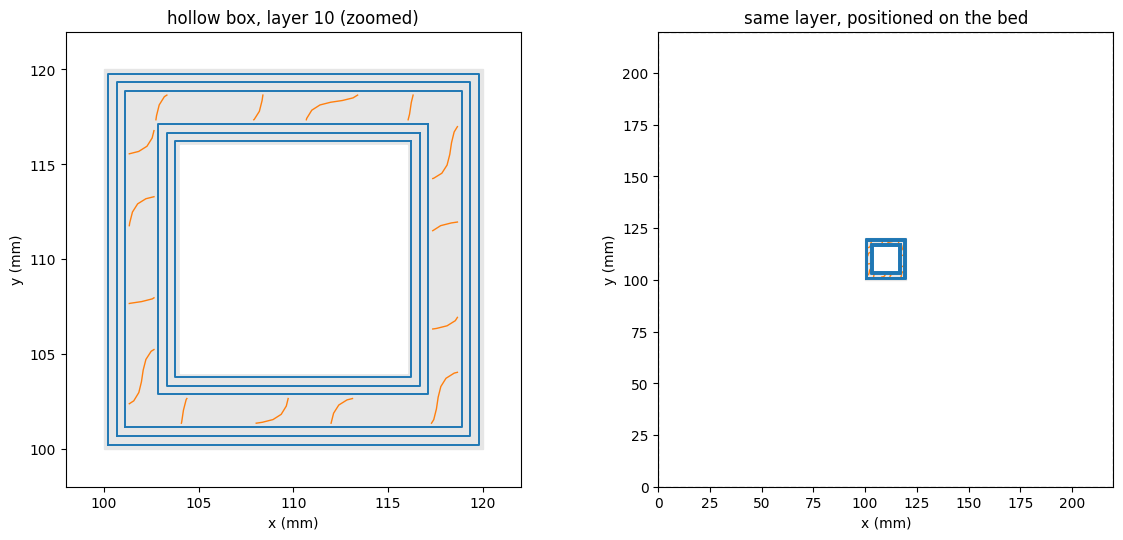

In [16]:
# cfg = PrintConfig(layer_height=0.25, num_perimeters=3, infill_density=0.15)

# hollow_layers = slice_stl_to_gcode("hollow_box.stl", "hollow_box.gcode", cfg,
#                                    pattern=sine_pattern)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
# plot_layer(hollow_layers[10], ax=axes[0], title="hollow box, layer 10 (zoomed)")
# plot_layer(hollow_layers[10], ax=axes[1], show_bed=True, cfg=cfg,
#            title="same layer, positioned on the bed")
# plt.tight_layout()
# plt.show()

The model sits centered on the bed (the default `center_x`/`center_y`), the
three walls follow both the outer edge and the hole, and the sine infill fills
only the material between them.

In [17]:
# Solid cube, and a 3D look at the alternating infill direction.
# cube_cfg = PrintConfig(layer_height=0.2, num_perimeters=2, infill_density=0.2)
# cube_layers = slice_model(load_stl("cube.stl"), cube_cfg, pattern=sine_pattern)

# plot_toolpaths_3d(cube_layers, every=6)
# plt.tight_layout()
# plt.show()

## 10. The whole library at a glance

Same part, same density — every pattern in `PATTERNS`. The first four are the
1-D sweep family; everything after them is parametric or polar.

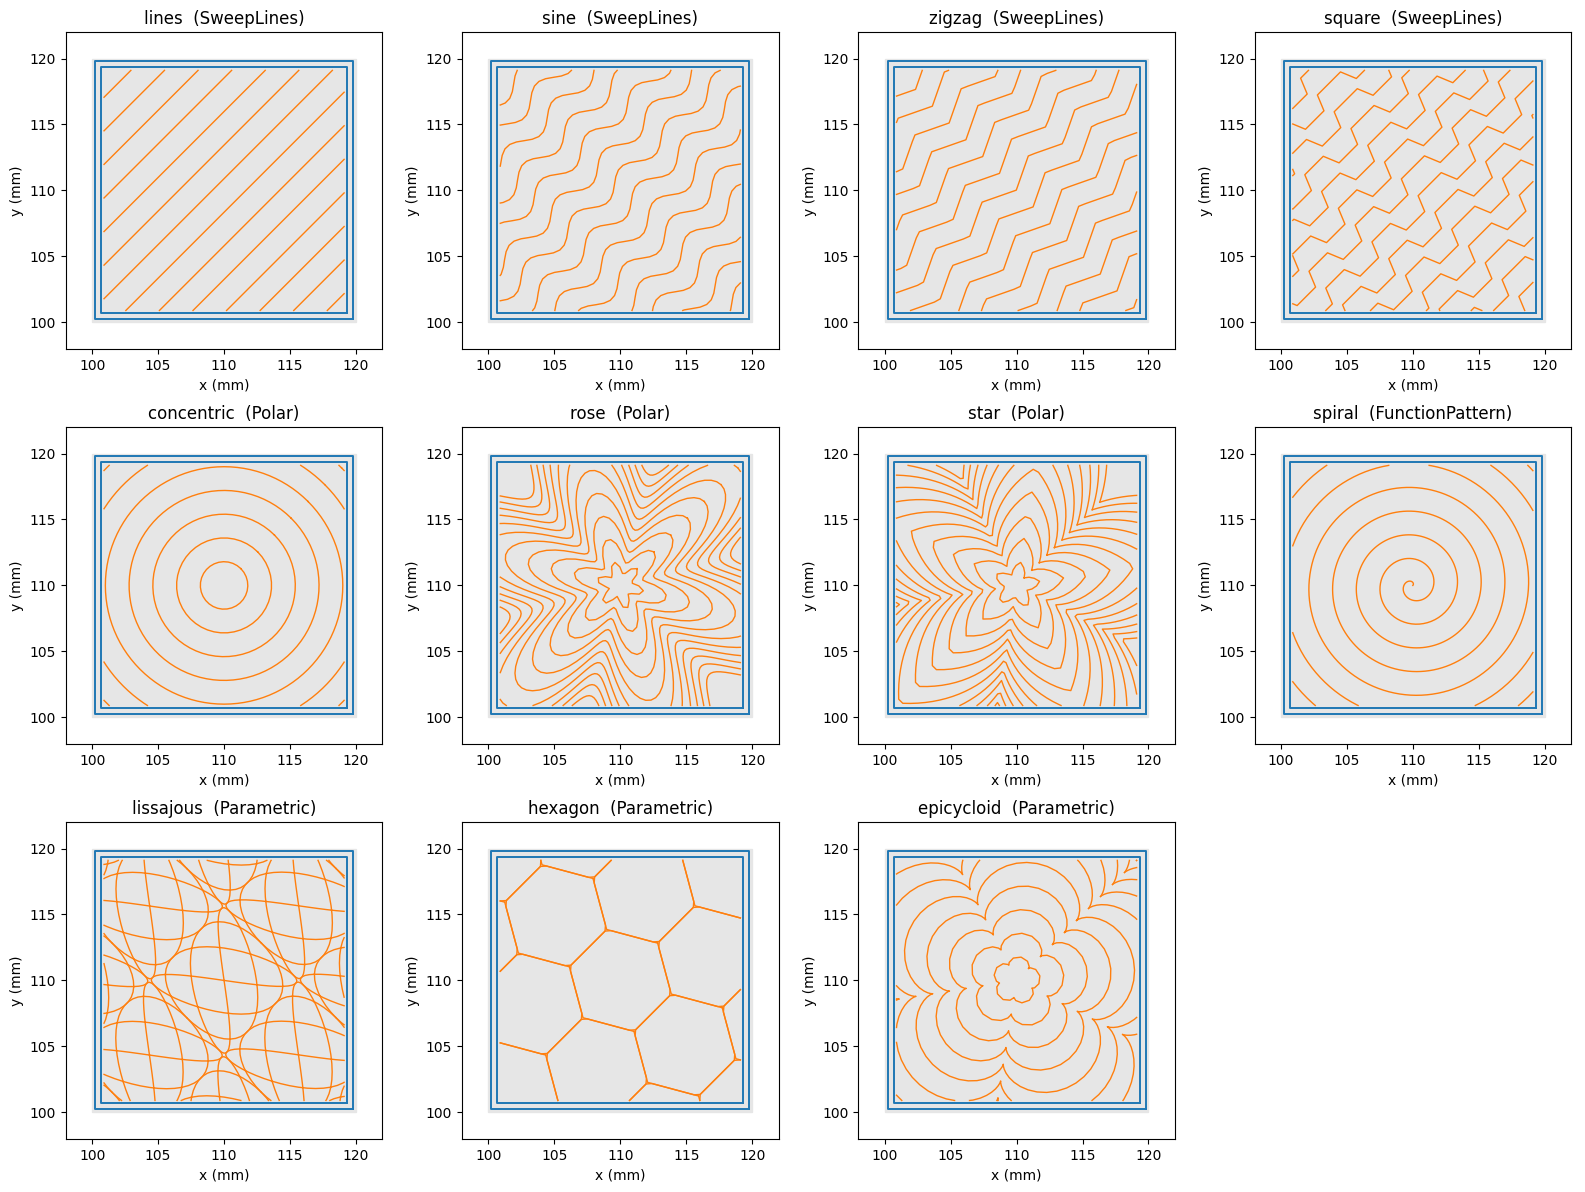

In [18]:
compare_cfg = PrintConfig(infill_density=0.25, num_perimeters=2,
                          alternate_infill_angle=False)
_cube = load_stl("cube.stl")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (name, pat) in zip(axes.ravel(), PATTERNS.items()):
    layers = slice_model(_cube, compare_cfg, pattern=pat, verbose=False)
    kind = type(as_pattern(pat)).__name__
    plot_layer(layers[10], ax=ax, title=f"{name}  ({kind})")
for ax in axes.ravel()[len(PATTERNS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. Parametric and polar infill

### Polar: `r(theta)`

`Polar` defaults to `fill="nest"`, which normalizes your curve to radius 1 and
redraws it at radius `spacing`, `2*spacing`, ... out to the edge of the part.
So `r(theta)` describes the *shape* of one ring and nesting does the filling.

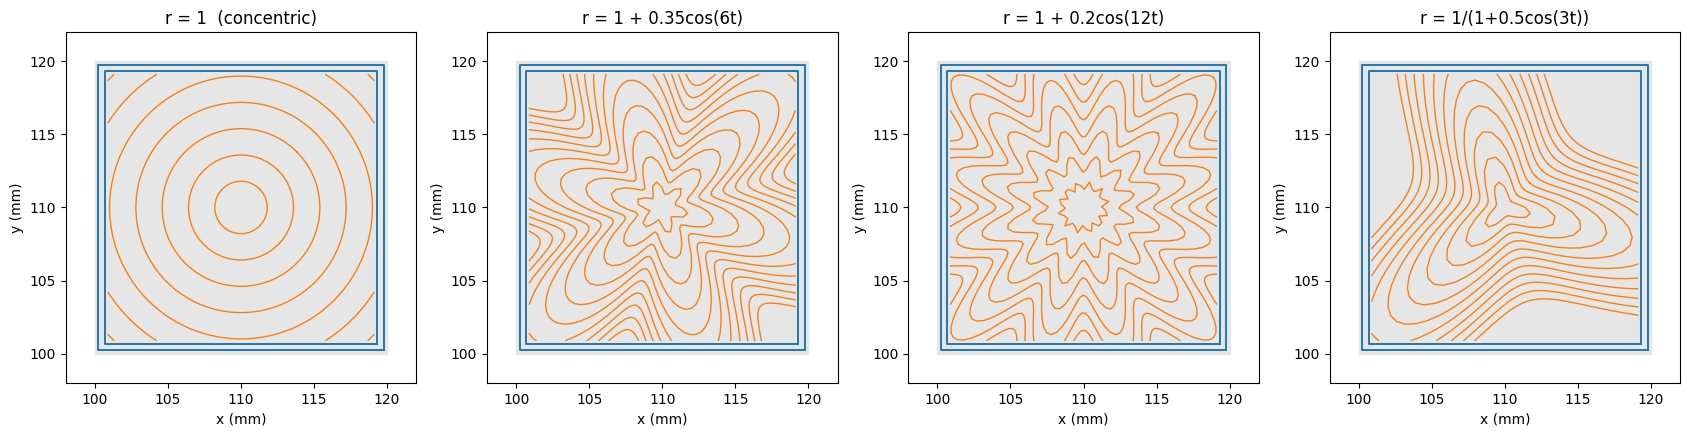

In [19]:
polar_cfg = PrintConfig(infill_density=0.25, num_perimeters=2,
                        alternate_infill_angle=False)

polar_demos = {
    "r = 1  (concentric)": Polar(lambda th: 1.0),
    "r = 1 + 0.35cos(6t)": Polar(lambda th: 1 + 0.35 * math.cos(6 * th)),
    "r = 1 + 0.2cos(12t)": Polar(lambda th: 1 + 0.2 * math.cos(12 * th)),
    "r = 1/(1+0.5cos(3t))": Polar(lambda th: 1.0 / (1 + 0.5 * math.cos(3 * th))),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (label, pat) in zip(axes, polar_demos.items()):
    layers = slice_model(_cube, polar_cfg, pattern=pat, verbose=False)
    plot_layer(layers[10], ax=ax, title=label)
plt.tight_layout()
plt.show()

### The spiral case

A spiral already reaches every part of the layer, so it needs no nesting or
tiling — it is emitted as one unbroken curve. Clipping cuts it where it
leaves the region (on this square part, near the middle of each edge), so it
arrives as a few long arcs rather than many short lines. On a round part it
would survive as a single continuous extrusion.

--- cube ---
  straight lines       14 infill path(s),   336.7 mm of extrusion
  concentric rings     15 infill path(s),   343.3 mm of extrusion
  spiral                9 infill path(s),   337.1 mm of extrusion
--- cylinder ---
  straight lines       10 infill path(s),   265.2 mm of extrusion
  concentric rings      5 infill path(s),   289.5 mm of extrusion
  spiral                1 infill path(s),   264.9 mm of extrusion


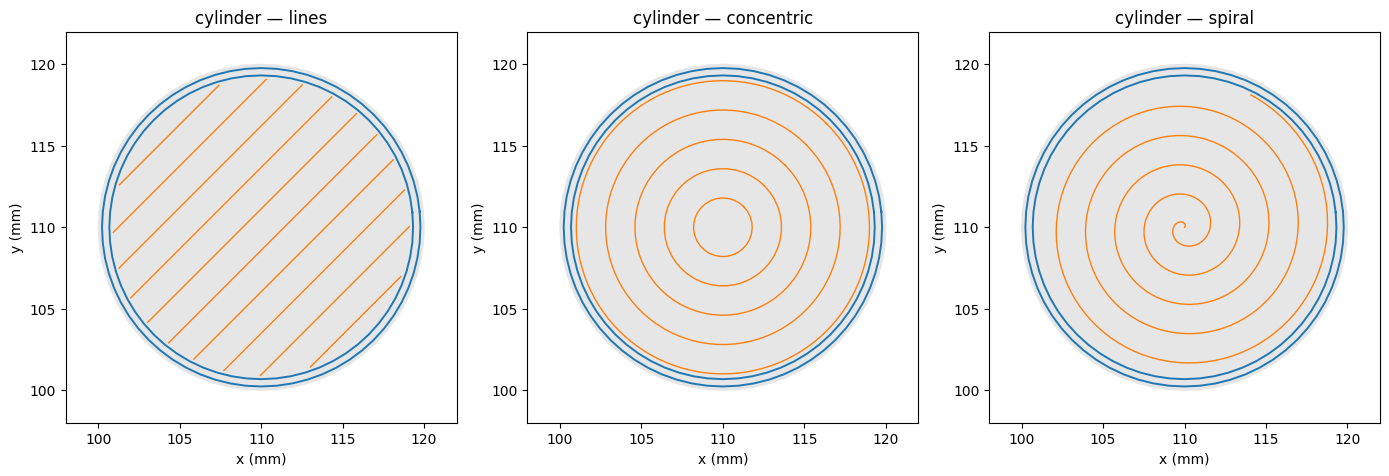

  concentric rings     15 infill path(s),   343.3 mm of extrusion


  spiral                9 infill path(s),   337.1 mm of extrusion
--- cylinder ---


  straight lines       10 infill path(s),   265.2 mm of extrusion


  concentric rings      5 infill path(s),   289.5 mm of extrusion


  spiral                1 infill path(s),   264.9 mm of extrusion


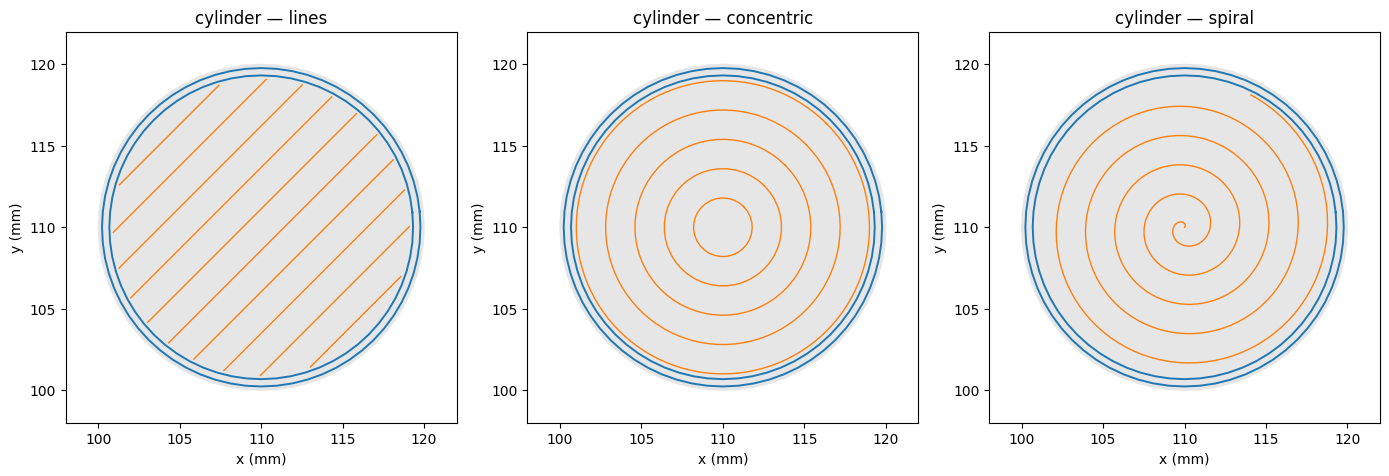

In [20]:
_cylinder = load_stl("cylinder.stl")

for part_name, mesh in (("cube", _cube), ("cylinder", _cylinder)):
    print(f"--- {part_name} ---")
    for name, pat in (("straight lines", lines_pattern),
                      ("concentric rings", concentric_pattern()),
                      ("spiral", spiral_pattern())):
        layer = slice_model(mesh, polar_cfg, pattern=pat, verbose=False)[10]
        print(f"  {name:18s} {len(layer.infill):4d} infill path(s), "
              f"{layer.path_length:7.1f} mm of extrusion")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (label, pat) in zip(axes, (("lines", lines_pattern),
                                   ("concentric", concentric_pattern()),
                                   ("spiral", spiral_pattern()))):
    layers = slice_model(_cylinder, polar_cfg, pattern=pat, verbose=False)
    plot_layer(layers[10], ax=ax, title=f"cylinder — {label}")
plt.tight_layout()
plt.show()

### Parametric: `p(t) -> (x, y)`

A parametric curve is written directly in the layer's XY plane, in mm.
`fill="tile"` repeats it on a grid; `fill="nest"` scales it outwards;
`fill="once"` draws it exactly as written.

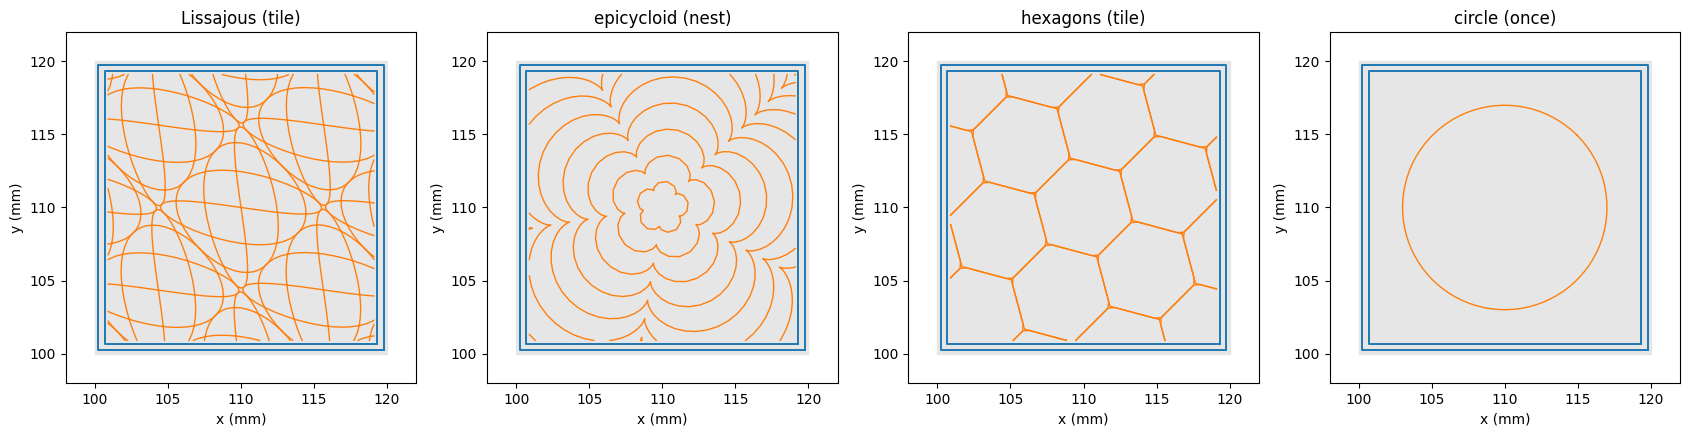

In [21]:
param_demos = {
    "Lissajous (tile)": lissajous_pattern(3, 4),
    "epicycloid (nest)": epicycloid_pattern(5),
    "hexagons (tile)": hexagon_pattern(3.5),
    "circle (once)": Parametric(lambda t: (7 * math.cos(t), 7 * math.sin(t)),
                                fill="once"),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (label, pat) in zip(axes, param_demos.items()):
    layers = slice_model(_cube, polar_cfg, pattern=pat, verbose=False)
    plot_layer(layers[10], ax=ax, title=label)
plt.tight_layout()
plt.show()

### Patterns that change with height

`InfillContext` carries `layer_index` and `z`, so a pattern can evolve up the
part. `FunctionPattern` is the escape hatch that hands you the context
directly — here the number of petals grows as the print gets taller.

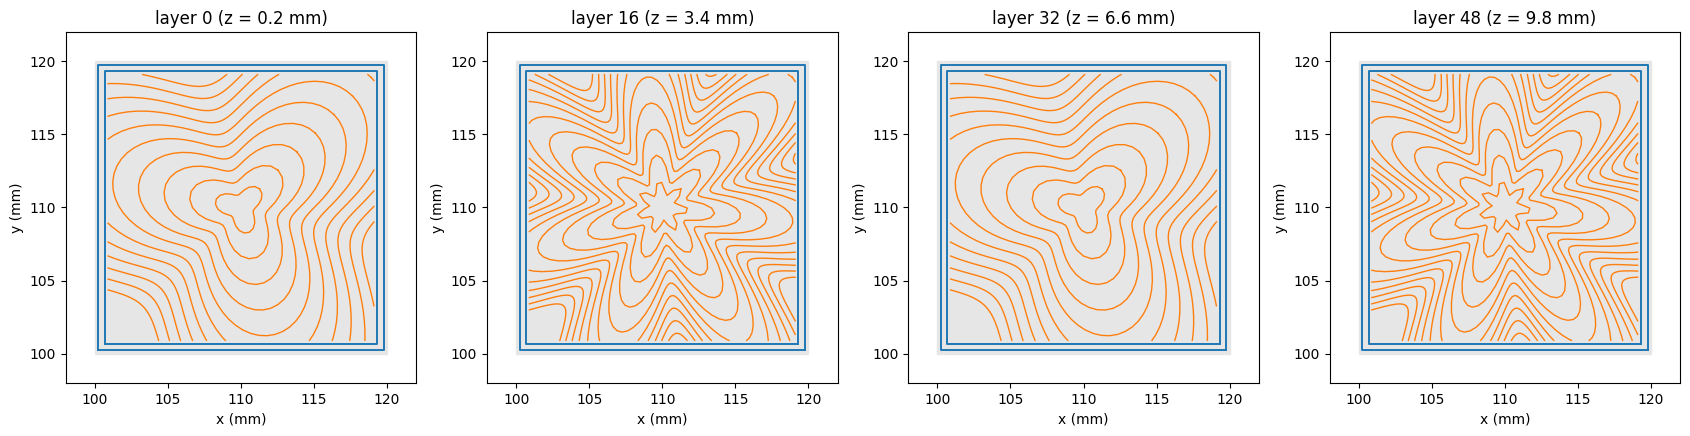

In [22]:
def growing_rose(ctx: InfillContext) -> List[Path2]:
    """A rose whose petal count increases every few layers."""
    petals = 3 + (ctx.layer_index // 4) % 8
    inner = Polar(lambda th: 1 + 0.35 * math.cos(petals * th))
    return inner.generate(ctx)


twist_layers = slice_model(_cube, polar_cfg, pattern=FunctionPattern(growing_rose),
                           verbose=False)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, idx in zip(axes, (0, 16, 32, 48)):
    plot_layer(twist_layers[idx], ax=ax,
               title=f"layer {idx} (z = {twist_layers[idx].print_z:.1f} mm)")
plt.tight_layout()
plt.show()

## 12. Gcode Export

Whichever kind you use, the pattern is evaluated in the part-local frame:
`(0, 0)` is the middle of the part, and `x` runs along the infill angle.

- **Sweep** `f(x) -> y`: `x` in mm along the infill direction; keep the
  peak-to-peak amplitude under the line spacing to avoid collisions.
- **Parametric** `p(t) -> (x, y)`: output in mm.
- **Polar** `r(theta) -> radius`: normalized when nesting, mm when `fill="once"`.

Curves are sampled to roughly `infill_sample_step` mm (0.5 mm default) — lower
it for sharp corners, raise it for smaller files.

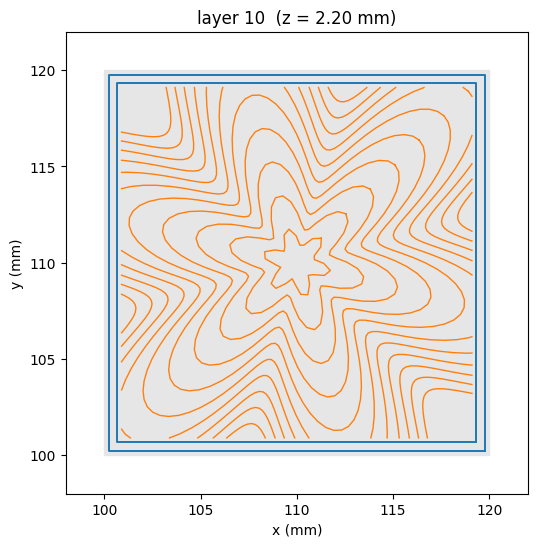

In [23]:
cfg = PrintConfig(infill_density=0.25, num_perimeters=2, alternate_infill_angle=False)
mesh = load_stl("cube.stl")

pattern = Polar(lambda theta: 1 + 0.35*math.cos(6*theta))   
layers = slice_model(mesh, cfg, pattern=pattern, verbose=False)

plot_layer(layers[10])                                 
with open("polarTest.gcode", "w") as f:
    f.write(layers_to_gcode(layers, cfg))

## 13. Export

Slice once, inspect, then emit G-code from the layers you already have.

sliced 100 layers in 1.69s  |  55.7 m of extrusion path
wrote cube_custom.gcode: 99920 lines

--- first 24 lines ---
; Generated by the notebook slicer
; layer_height=0.2 extrusion_width=0.45 perimeters=2 infill_density=0.25
; nozzle_diameter=0.4mm filament_diameter=1.75mm
G21 ; units: millimeters
G90 ; absolute X/Y/Z positioning
M83 ; relative extrusion
M140 S60.0 ; set bed temp, don't wait
M104 S215.0 ; set nozzle temp, don't wait
M190 S60.0 ; wait for bed temp
M109 S215.0 ; wait for nozzle temp
;TYPE:Custom
G28 ; home all axes
G92 E0 ; reset extruder position
;LAYER_CHANGE
;Z:0.200
;HEIGHT:0.200
; LAYER:0
G1 F7200 Z0.2000
;TYPE:External perimeter
;WIDTH:0.4500
G1 F2100 E-1.00000
G0 F7200 X100.2250 Y100.2250
G1 F2100 E1.00000
G1 F1200 X100.2250 Y119.7750 E0.73152

--- last 6 lines ---
; End of print
G1 F2100 E-1.00000
M104 S0 ; nozzle heater off
M140 S0 ; bed heater off
M84 ; disable motors
; filament used: 2085.0 mm


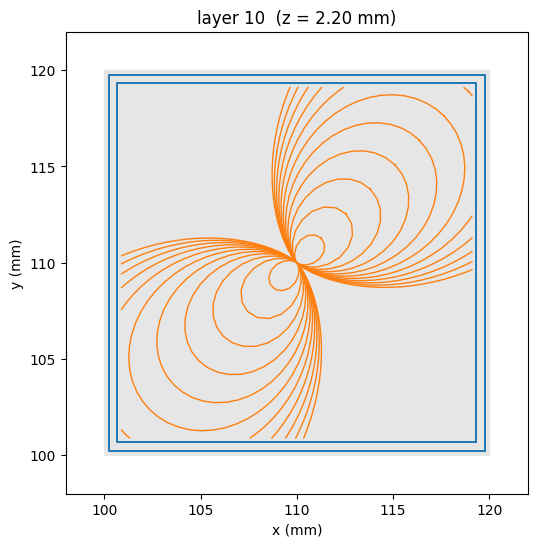

In [31]:
final_cfg = PrintConfig(
    layer_height=0.2,
    extrusion_width=0.45,
    num_perimeters=2,
    infill_density=0.25,
    nozzle_diameter=0.4,
    filament_diameter=1.75,
    nozzle_temp=215,
    bed_temp=60,
    alternate_infill_angle = 5
)

pattern = Polar(lambda theta: 1+ np.cos(2*theta))

layers = slice_model(load_stl("cube.stl"), final_cfg, pattern=pattern)
gcode = layers_to_gcode(layers, final_cfg)

plot_layer(layers[10])
with open("cube_custom.gcode", "w") as f:
    f.write(gcode)

print(f"wrote cube_custom.gcode: {len(gcode.splitlines())} lines\n")
print("--- first 24 lines ---")
print("\n".join(gcode.splitlines()[:24]))
print("\n--- last 6 lines ---")
print("\n".join(gcode.splitlines()[-6:]))

### Checking the file a viewer's way

Re-read the finished file the way a G-code viewer does: count layer changes,
confirm each one declares a Z and a height, and confirm every extrusion falls
under a role tag. If any of these come back zero, the viewer will show one
unscrollable blob instead of a stack of layers.

In [22]:
def check_gcode(path: str) -> Dict[str, object]:
    """Sanity-check a G-code file for viewer compatibility."""
    layer_changes = z_tags = height_tags = width_tags = 0
    roles: Dict[str, int] = {}
    extrusions_without_role = 0
    current_role = None
    zs = []

    for line in open(path):
        line = line.strip()
        if line.startswith(";LAYER_CHANGE"):
            layer_changes += 1
            current_role = None
        elif line.startswith(";Z:"):
            z_tags += 1
            zs.append(float(line[3:]))
        elif line.startswith(";HEIGHT:"):
            height_tags += 1
        elif line.startswith(";WIDTH:"):
            width_tags += 1
        elif line.startswith(";TYPE:"):
            current_role = line[6:]
        elif line.startswith("G1") and " E" in line and " X" in line:
            if current_role is None:
                extrusions_without_role += 1
            else:
                roles[current_role] = roles.get(current_role, 0) + 1

    return {
        "layer_changes": layer_changes,
        "z_tags": z_tags,
        "height_tags": height_tags,
        "width_tags": width_tags,
        "distinct_z": len(set(zs)),
        "z_range": (min(zs), max(zs)) if zs else None,
        "extrusions_by_role": roles,
        "extrusions_without_role": extrusions_without_role,
    }


report = check_gcode("cube_custom.gcode")
for key, value in report.items():
    print(f"{key:26s} {value}")

assert report["layer_changes"] == report["distinct_z"] > 1, "layers not detectable"
assert report["extrusions_without_role"] == 0, "untagged extrusions present"
print("\nOK: layers and extrusion roles are all tagged.")

layer_changes              100


z_tags                     100
height_tags                100
width_tags                 300
distinct_z                 100
z_range                    (0.2, 20.0)
extrusions_by_role         {'External perimeter': 400, 'Perimeter': 400, 'Internal infill': 39600}
extrusions_without_role    0

OK: layers and extrusion roles are all tagged.


## Reference

**Typical use**

```python
cfg = PrintConfig(layer_height=0.2, num_perimeters=3, infill_density=0.3)
layers = slice_model(load_stl("part.stl"), cfg, pattern=my_pattern)
plot_layer(layers[10])                      # check it
open("part.gcode", "w").write(layers_to_gcode(layers, cfg))
```

**The three pattern kinds**

```python
SweepLines(lambda x: 0.6*math.sin(x))              # f(x) -> y offset
Parametric(lambda t: (8*math.sin(3*t), 8*math.sin(4*t)), fill="nest")
Polar(lambda th: 1 + 0.35*math.cos(6*th))          # r(theta), nested
FunctionPattern(gen)                               # raw: gen(ctx) -> [path, ...]
```

A bare `f(x)` still works anywhere a pattern is expected — `as_pattern()`
wraps it as `SweepLines`.

| Fill strategy | Effect | Good for |
|---|---|---|
| `"once"` | curve drawn as written, in mm | spirals, single motifs |
| `"nest"` | normalized, redrawn at `k*spacing` | rings, roses, stars, Lissajous |
| `"tile"` | repeated on a grid | hexagons, repeating motifs |

Patterns are evaluated in a **part-local frame**: `(0, 0)` is the middle of
the model's footprint, `+x` runs along `infill_angle`. `InfillContext` also
carries `layer_index`, `z`, `spacing` and `max_radius`, so a pattern can
change as the print gets taller.

**The settings that matter most**

| Setting | Default | Notes |
|---|---|---|
| `layer_height` | 0.2 mm | |
| `extrusion_width` | 0.45 mm | slightly wider than the nozzle is normal |
| `num_perimeters` | 2 | wall loops |
| `infill_density` | 0.2 | line spacing = `extrusion_width / density` |
| `nozzle_diameter` | 0.4 mm | |
| `filament_diameter` | 1.75 mm | drives the extrusion math |
| `nozzle_temp` / `bed_temp` | 200 / 60 C | |
| `center_x` / `center_y` | `None` | `None` = middle of the bed |
| `infill_angle` | 45 deg | `alternate_infill_angle` adds 90 deg on odd layers |
| `infill_sample_step` | 0.5 mm | curve sampling resolution |
| `optimize_travel` | `True` | greedy reordering of infill paths |

**Deliberately not implemented:** support material, overhang and bridging
detection, variable layer height, multi-material, mesh repair. Extrusion uses
a plain rectangular bead model (`width x height`), which slightly
under-estimates a real bead's rounded cross-section.